In [1]:
import os
for dp, dn, fn in os.walk("/kaggle/input"):
    depth = dp.count(os.sep) - 2
    if depth <= 3:
        print(dp)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/gpiosenka
/kaggle/input/datasets/gpiosenka/sports-classification


In [2]:
import os, time, copy, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

DATA_DIR = Path("/kaggle/input/datasets/gpiosenka/sports-classification")
TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR  = DATA_DIR / "test"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

BATCH_SIZE = 64
NUM_EPOCHS = 15
LR_HEAD    = 1e-3   
LR_BACKBONE= 1e-4  
IMG_SIZE   = 224
SEED       = 42

torch.manual_seed(SEED); np.random.seed(SEED)

Device: cuda


In [3]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
valid_ds = datasets.ImageFolder(VALID_DIR, transform=eval_tf)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=eval_tf)

NUM_CLASSES = len(train_ds.classes)
print("Классов:", NUM_CLASSES)
print("Train/Valid/Test:", len(train_ds), len(valid_ds), len(test_ds))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Классов: 100
Train/Valid/Test: 13492 500 500


In [4]:
def build_model(num_classes: int) -> nn.Module:
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes),
    )

    for name, p in model.named_parameters():
        p.requires_grad = name.startswith("fc.")

    return model

model = build_model(NUM_CLASSES).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Обучаемых параметров: {trainable:,} из {total:,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 103MB/s] 


Обучаемых параметров: 204,900 из 23,712,932


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_HEAD)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

def run_epoch(loader, train: bool):
    model.train() if train else model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            if train:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss   += loss.item() * x.size(0)
            total_correct+= (out.argmax(1) == y).sum().item()
            total_n      += x.size(0)
    return total_loss / total_n, total_correct / total_n

history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}
best_acc, best_state = 0.0, None

WARMUP_EPOCHS = 5
for epoch in range(NUM_EPOCHS):
    if epoch == WARMUP_EPOCHS:
        for p in model.parameters():
            p.requires_grad = True
        optimizer = optim.AdamW(model.parameters(), lr=LR_BACKBONE)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS)
        print(">>> Разморозили backbone, lr =", LR_BACKBONE)

    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(valid_loader, train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.3f} acc {va_acc:.3f} | "
          f"{time.time()-t0:.1f}s")

    if va_acc > best_acc:
        best_acc = va_acc
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, "/kaggle/working/best_model.pt")

print("Лучшая val accuracy:", best_acc)

Epoch 01/15 | train loss 2.443 acc 0.592 | val loss 1.087 acc 0.878 | 59.1s
Epoch 02/15 | train loss 1.006 acc 0.840 | val loss 0.619 acc 0.912 | 44.2s
Epoch 03/15 | train loss 0.702 acc 0.872 | val loss 0.452 acc 0.934 | 46.9s
Epoch 04/15 | train loss 0.546 acc 0.898 | val loss 0.378 acc 0.924 | 45.6s
Epoch 05/15 | train loss 0.456 acc 0.914 | val loss 0.326 acc 0.934 | 46.2s
>>> Разморозили backbone, lr = 0.0001
Epoch 06/15 | train loss 0.198 acc 0.945 | val loss 0.112 acc 0.962 | 138.3s
Epoch 07/15 | train loss 0.079 acc 0.979 | val loss 0.086 acc 0.972 | 138.6s
Epoch 08/15 | train loss 0.039 acc 0.990 | val loss 0.067 acc 0.980 | 138.2s
Epoch 09/15 | train loss 0.029 acc 0.993 | val loss 0.060 acc 0.982 | 138.5s
Epoch 10/15 | train loss 0.018 acc 0.996 | val loss 0.059 acc 0.980 | 137.5s
Epoch 11/15 | train loss 0.013 acc 0.998 | val loss 0.056 acc 0.984 | 138.1s
Epoch 12/15 | train loss 0.010 acc 0.998 | val loss 0.061 acc 0.982 | 138.2s
Epoch 13/15 | train loss 0.007 acc 0.999 | 

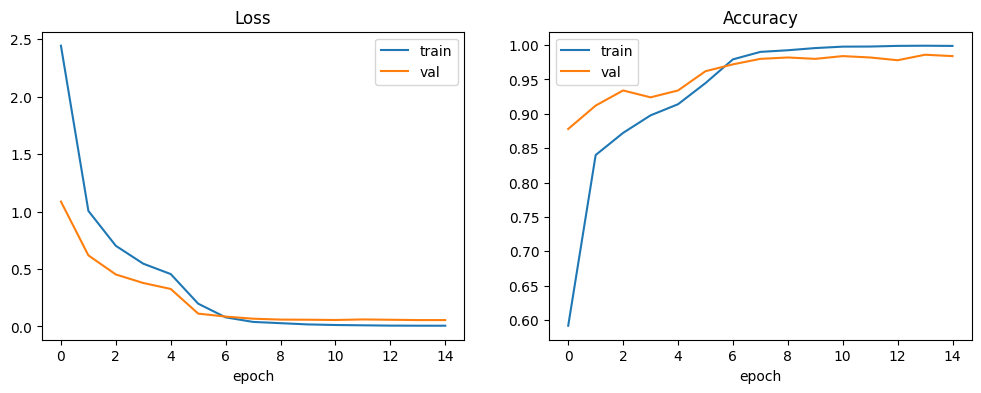

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].legend(); ax[0].set_xlabel("epoch")
ax[1].plot(history["train_acc"],  label="train"); ax[1].plot(history["val_acc"],  label="val")
ax[1].set_title("Accuracy"); ax[1].legend(); ax[1].set_xlabel("epoch")
plt.show()

Test accuracy: 0.9840
                       precision    recall  f1-score   support

           air hockey      1.000     1.000     1.000         5
      ampute football      1.000     1.000     1.000         5
              archery      1.000     1.000     1.000         5
        arm wrestling      1.000     1.000     1.000         5
         axe throwing      1.000     1.000     1.000         5
         balance beam      1.000     1.000     1.000         5
        barell racing      1.000     1.000     1.000         5
             baseball      1.000     1.000     1.000         5
           basketball      0.833     1.000     0.909         5
       baton twirling      1.000     1.000     1.000         5
            bike polo      1.000     1.000     1.000         5
            billiards      1.000     1.000     1.000         5
                  bmx      1.000     1.000     1.000         5
              bobsled      1.000     1.000     1.000         5
              bowling      1.000

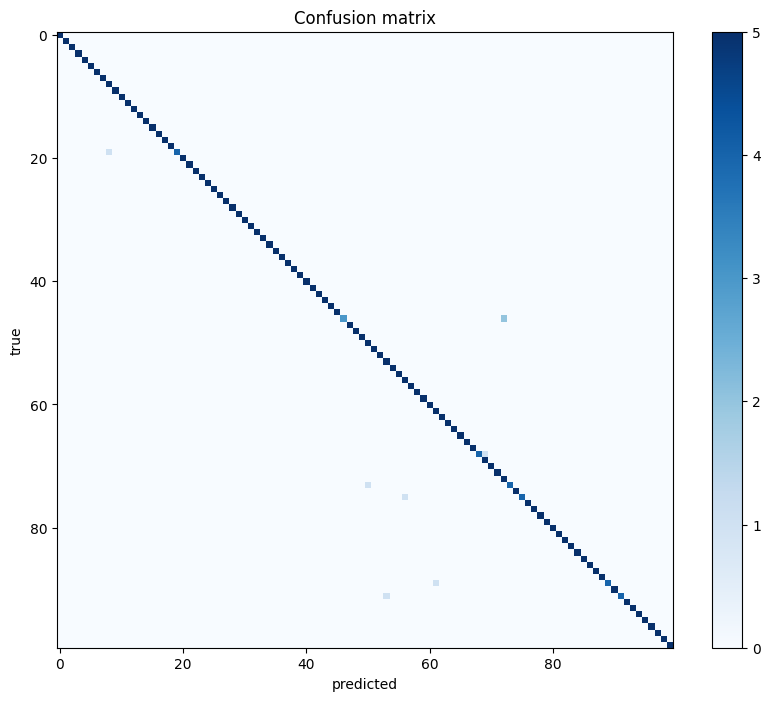

In [7]:
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(torch.load("/kaggle/working/best_model.pt"))
model.eval()

all_pred, all_true = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x)
        all_pred.append(out.argmax(1).cpu().numpy())
        all_true.append(y.numpy())
all_pred = np.concatenate(all_pred); all_true = np.concatenate(all_true)

test_acc = (all_pred == all_true).mean()
print(f"Test accuracy: {test_acc:.4f}")

print(classification_report(all_true, all_pred, target_names=train_ds.classes, digits=3))

cm = confusion_matrix(all_true, all_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues"); plt.title("Confusion matrix"); plt.colorbar()
plt.xlabel("predicted"); plt.ylabel("true")
plt.show()

In [8]:
from PIL import Image

idx_to_class = {i: c for c, i in train_ds.class_to_idx.items()}

def predict_image(path: str, topk: int = 3):
    img = Image.open(path).convert("RGB")
    x = eval_tf(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1)[0].cpu().numpy()
    top = probs.argsort()[-topk:][::-1]
    return [(idx_to_class[int(i)], float(probs[i])) for i in top]

sample_path = next((TEST_DIR).rglob("*.jpg"))
print(sample_path)
print(predict_image(str(sample_path)))

/kaggle/input/datasets/gpiosenka/sports-classification/test/bobsled/5.jpg
[('bobsled', 0.9999339580535889), ('luge', 6.353699427563697e-05), ('formula 1 racing', 2.1686039417545544e-06)]
